# **Mount Google Drive and Libraries**

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# #Why doesn't my library thingy work?
# #It is called a function
# import sys
# sys.path.insert(0, '/content/drive/MyDrive/255 Project Data/')
# import library_install as lib

Installing ox...
ox installed successfully!
networkx is already installed.
numpy is already installed.
matplotlib.pyplot is already installed.
seaborn is already installed.
math is already installed.
Installing contextily...
contextily installed successfully!
geopandas is already installed.
pandas is already installed.


In [ ]:
#For the purpose of reproducability, use this code block instead
import os

# Set base directory relative to the notebook's location
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Data")

In [3]:
#Need all these handy libraries
!pip install osmnx
import sys
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile
import folium
import branca.colormap as cm
import osmnx as ox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.0 MB/s eta 0:00:00


# **Import Data and Clean**

In [4]:
tcac_path = os.path.join(DATA_DIR, "raw/shapefile (2).zip")

In [5]:
#I had no clue to unzip a zip file so I had to look this shit up
# Define the path to unzip the shapefile to
unzip_path = "/content/unzipped_shapefile_data"

# Ensure the unzip directory exists
os.makedirs(unzip_path, exist_ok=True)

# Unzip the shapefile
with zipfile.ZipFile(tcac_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_path)

# Find the .shp or .gpkg file in the unzipped directory
shp_gpkg_file = None
for root, dirs, files in os.walk(unzip_path):
    for file in files:
        if file.endswith('.shp') or file.endswith('.gpkg'):
            shp_gpkg_file = os.path.join(root, file)
            break
    if shp_gpkg_file:
        break

if shp_gpkg_file:
    tcac_gdf = gpd.read_file(shp_gpkg_file)
else:
    raise FileNotFoundError("No .shp or .gpkg file found in the unzipped directory.")

In [6]:
tcac_gdf.head()

,fips,fips_bg,county_name,region,pct_above_200_pov,pct_bachelors_plus,pct_employed,home_value,math_prof,read_prof,...,pct_asian,pct_black,pct_hispanic,pct_poc,pct_asian_cty,pct_black_cty,pct_hispanic_cty,pct_poc_cty,pov_seg_flag,geometry
0,06001400100,None,Alameda,Bay Area Region,0.912195,0.855738,0.784858,1802100.0,0.683709,0.711517,...,0.149321,NaN,NaN,0.319005,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.24691 37.88536, -122.2419..."
1,06001400200,None,Alameda,Bay Area Region,0.903966,0.839766,0.759462,1930000.0,0.665117,0.708944,...,0.122312,NaN,0.093645,0.327281,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.25742 37.8431, -122.2562 ..."
2,06001400300,None,Alameda,Bay Area Region,0.889960,0.807848,0.848602,1850900.0,0.431718,0.493813,...,0.106338,0.091496,NaN,0.412432,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26416 37.84, -122.26186 3..."
3,06001400400,None,Alameda,Bay Area Region,0.820271,0.807012,0.856718,1398400.0,0.553012,0.614790,...,0.096018,NaN,0.137429,0.398180,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.2618 37.84179, -122.2613 ..."
4,06001400500,None,Alameda,Bay Area Region,0.748166,0.681416,0.762106,1313500.0,0.528160,0.585979,...,0.080063,NaN,0.145735,0.556253,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26941 37.84811, -122.2683..."


In [7]:
tcac_gdf.columns

Index(['fips', 'fips_bg', 'county_name', 'region', 'pct_above_200_pov',
       'pct_bachelors_plus', 'pct_employed', 'home_value', 'math_prof',
       'read_prof', 'grad_rate', 'pct_not_frpm', 'pct_above_200_pov_median',
       'pct_bachelors_plus_median', 'pct_employed_median', 'home_value_median',
       'math_prof_median', 'read_prof_median', 'grad_rate_median',
       'pct_not_frpm_median', 'env_burden_flag', 'oppscore', 'oppcat',
       'pct_below_pov', 'pct_asian', 'pct_black', 'pct_hispanic', 'pct_poc',
       'pct_asian_cty', 'pct_black_cty', 'pct_hispanic_cty', 'pct_poc_cty',
       'pov_seg_flag', 'geometry'],
      dtype='object')

In [8]:
tcac_gdf_copy = tcac_gdf.copy()

In [9]:
tcac_gdf_copy.head(10)

,fips,fips_bg,county_name,region,pct_above_200_pov,pct_bachelors_plus,pct_employed,home_value,math_prof,read_prof,...,pct_asian,pct_black,pct_hispanic,pct_poc,pct_asian_cty,pct_black_cty,pct_hispanic_cty,pct_poc_cty,pov_seg_flag,geometry
0,06001400100,None,Alameda,Bay Area Region,0.912195,0.855738,0.784858,1802100.0,0.683709,0.711517,...,0.149321,NaN,NaN,0.319005,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.24691 37.88536, -122.2419..."
1,06001400200,None,Alameda,Bay Area Region,0.903966,0.839766,0.759462,1930000.0,0.665117,0.708944,...,0.122312,NaN,0.093645,0.327281,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.25742 37.8431, -122.2562 ..."
2,06001400300,None,Alameda,Bay Area Region,0.889960,0.807848,0.848602,1850900.0,0.431718,0.493813,...,0.106338,0.091496,NaN,0.412432,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26416 37.84, -122.26186 3..."
3,06001400400,None,Alameda,Bay Area Region,0.820271,0.807012,0.856718,1398400.0,0.553012,0.614790,...,0.096018,NaN,0.137429,0.398180,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.2618 37.84179, -122.2613 ..."
4,06001400500,None,Alameda,Bay Area Region,0.748166,0.681416,0.762106,1313500.0,0.528160,0.585979,...,0.080063,NaN,0.145735,0.556253,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26941 37.84811, -122.2683..."
5,06001400600,None,Alameda,Bay Area Region,0.825364,0.596764,0.856326,1215800.0,0.431718,0.493813,...,0.051610,0.277976,0.101175,0.590700,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26807 37.84414, -122.2651..."
6,06001400700,None,Alameda,Bay Area Region,0.751817,0.660954,0.849631,1098200.0,0.286626,0.386611,...,0.063124,0.239328,0.102861,0.493642,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.27777 37.84752, -122.2774..."
7,06001400800,None,Alameda,Bay Area Region,0.764397,0.650992,0.858197,1054000.0,0.427100,0.481363,...,0.150556,NaN,0.130046,0.467379,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.28874 37.84999, -122.2862..."
8,06001400900,None,Alameda,Bay Area Region,0.788881,0.445122,0.882579,1101100.0,0.260285,0.367680,...,NaN,0.275799,NaN,0.651526,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.28558 37.83978, -122.2831..."
9,06001401000,None,Alameda,Bay Area Region,0.786656,0.569149,0.798787,943700.0,0.199114,0.330239,...,0.060959,0.374943,0.137234,0.695972,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.27871 37.82715, -122.2778..."


In [10]:
tcac_gdf_copy.columns

Index(['fips', 'fips_bg', 'county_name', 'region', 'pct_above_200_pov',
       'pct_bachelors_plus', 'pct_employed', 'home_value', 'math_prof',
       'read_prof', 'grad_rate', 'pct_not_frpm', 'pct_above_200_pov_median',
       'pct_bachelors_plus_median', 'pct_employed_median', 'home_value_median',
       'math_prof_median', 'read_prof_median', 'grad_rate_median',
       'pct_not_frpm_median', 'env_burden_flag', 'oppscore', 'oppcat',
       'pct_below_pov', 'pct_asian', 'pct_black', 'pct_hispanic', 'pct_poc',
       'pct_asian_cty', 'pct_black_cty', 'pct_hispanic_cty', 'pct_poc_cty',
       'pov_seg_flag', 'geometry'],
      dtype='object')

In [11]:
#Using .loc to isolate the columns I want
#From now on, I am using .drop
tcac_cleaned = tcac_gdf_copy.loc[:,['fips',
    'county_name',
    'region',
    'geometry',
    'oppscore',
    'oppcat',
    'pct_poc',
    'pct_below_pov',
    'pct_bachelors_plus',
    'pct_employed']
                                 ]

In [12]:
tcac_cleaned.head()

/usr/local/lib/python3.12/dist-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


,fips,county_name,region,geometry,oppscore,oppcat,pct_poc,pct_below_pov,pct_bachelors_plus,pct_employed
0,06001400100,Alameda,Bay Area Region,"MULTIPOLYGON (((-122.24691 37.88536, -122.2419...",9.0,Highest Resource,0.319005,NaN,0.855738,0.784858
1,06001400200,Alameda,Bay Area Region,"MULTIPOLYGON (((-122.25742 37.8431, -122.2562 ...",8.0,Highest Resource,0.327281,NaN,0.839766,0.759462
2,06001400300,Alameda,Bay Area Region,"MULTIPOLYGON (((-122.26416 37.84, -122.26186 3...",7.0,High Resource,0.412432,0.054319,0.807848,0.848602
3,06001400400,Alameda,Bay Area Region,"MULTIPOLYGON (((-122.2618 37.84179, -122.2613 ...",8.0,Highest Resource,0.398180,NaN,0.807012,0.856718
4,06001400500,Alameda,Bay Area Region,"MULTIPOLYGON (((-122.26941 37.84811, -122.2683...",7.0,High Resource,0.556253,0.104036,0.681416,0.762106


# **Geospatial Data Analysis**

In [13]:
#Need to set my crs for my tcac data so I can match it with my city limits data
tcac_cleaned = tcac_cleaned.to_crs('EPSG:4326')

In [14]:
#This is loading in my Oakland City Limits geojson file
oak_boundaries = gpd.read_filegpd.read_file(
    os.path.join(DATA_DIR, "raw/City_Limits_20260416.geojson")
)

In [15]:
#This is loading in my Berkeley City Limits shapefile
#I know I shouldn't use a shapefile but it is what I can find
#Maybe convert to parquet
berk_boundaries = gpd.read_file(
    os.path.join(DATA_DIR, "berkeley city limits.zip")
)

In [16]:
#data inspection
#gonna drop unnecessary columns
oak_boundaries

,:id,:version,:created_at,:updated_at,objectid_1,objectid,id,name,shape_leng,shape_le_1,shape_area,geometry
0,row-mzgn~xmsh~w2ei,rv-zie8-ngv4_9ipq,2015-12-01 00:30:49.516000+00:00,2015-12-01 00:30:49.516000+00:00,11,11,0,Oakland,425119.982265,425250.72096,2159947540.06,"MULTIPOLYGON (((-122.22421 37.76281, -122.2247..."


In [17]:
#inspecting my data
berk_boundaries

,areasqmile,lengthmile,geometry
0,10.511169,21.764084,"POLYGON ((-122.27132 37.90495, -122.27037 37.9..."


In [18]:
oak_boundaries.columns

Index([':id', ':version', ':created_at', ':updated_at', 'objectid_1',
       'objectid', 'id', 'name', 'shape_leng', 'shape_le_1', 'shape_area',
       'geometry'],
      dtype='object')

In [19]:
#only keeping the relevant columns
oakland_cleaned = oak_boundaries.loc[:,['name',
'geometry'
]
]
oakland_cleaned = oakland_cleaned.rename(columns={'name':'city'})

In [20]:
oakland_cleaned

,city,geometry
0,Oakland,"MULTIPOLYGON (((-122.22421 37.76281, -122.2247..."


In [21]:
#gonna clean the berekely file as well.
#Convert to parquet, add name column, remove unnecessary columns.
berk_cleaned = berk_boundaries[['geometry']].copy()
berk_cleaned ['city'] = 'Berkeley'
berk_cleaned = berk_cleaned[['city','geometry']]
print(berk_cleaned)

       city                                           geometry
0  Berkeley  POLYGON ((-122.27132 37.90495, -122.27037 37.9...


In [22]:
#yay it worked!
berk_cleaned

,city,geometry
0,Berkeley,"POLYGON ((-122.27132 37.90495, -122.27037 37.9..."


In [23]:
#okay, what I am doing here is projecting my oakland and berkeley boundaries to the same coordinate reference system
#matching it with the above cleaned tcac data for later visualization
oakland_cleaned = oakland_cleaned.to_crs(tcac_cleaned.crs)
berk_cleaned = berk_cleaned.to_crs(tcac_cleaned.crs)

oak_berk = gpd.GeoDataFrame(
    pd.concat([oakland_cleaned, berk_cleaned], ignore_index=True),
    crs=tcac_cleaned.crs
)

# **Dissolve and Repackage Data**
- Dissolve the Oakland and Berkeley layers to show TCAC data across boundaries.


In [24]:
#Now I am gonna dissolve any internal boundaries so I can get a single, cleaned Oakland-Berkeley boundary.
oak_berk = oak_berk.dissolve()

In [25]:
# ISSUE: I was having a problem displaying the dissolve with both within and intersects so I used this instead (I had to use AI to do this because I was so stuck). Create representative points with centroid
tcac_gdf["rep_point"] = tcac_gdf.geometry.representative_point()

# GeoDataFrame of those points for tcac
points_gdf = gpd.GeoDataFrame(
    tcac_gdf[["fips"]],
    geometry=tcac_gdf["rep_point"],
    crs=tcac_gdf.crs
)

# Because of the above step, spatial join now works correctly
points_joined = gpd.sjoin(
    points_gdf,
    oak_berk,
    predicate="within"
)

# Filter TCAC polygons using the join result
tcac_oak_berk = tcac_gdf[
    tcac_gdf["fips"].isin(points_joined["fips"])
].copy()

# drop helper column
tcac_oak_berk = tcac_oak_berk.drop(columns=["rep_point"])

<Axes: >

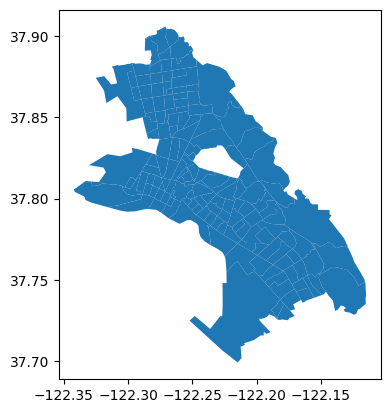

In [26]:
#Display polygons to see if the dissolved finally worked
tcac_oak_berk.plot()

# **Add OSMNX Data**
- Probably not using

In [27]:
polygon = tcac_oak_berk.geometry.union_all()
polygon = polygon.buffer(0)

In [28]:
bike_network = ox.graph_from_polygon(polygon, network_type='bike')

In [29]:
edges = ox.graph_to_gdfs(bike_network, nodes=False, edges=True)
edges = edges.to_crs(epsg=4326)
tcac_map = tcac_oak_berk.to_crs(epsg=4326)

# Calculate median; if all values are NaN, median will be NaN.
# In that case, use 0 as a fallback fill value.
median_oppscore = tcac_map['oppscore'].median()
if pd.isna(median_oppscore):
    fill_value = 0
else:
    fill_value = median_oppscore

# Fill NaN values in 'oppscore' and ensure column is float type
tcac_map['oppscore'] = tcac_map['oppscore'].fillna(fill_value).astype(float)

# **TCAC Mapping**
- Visualizing my data using folium (documentation I used is in the main notebook)
- Create interactive polygons to see if data is outputting correctly
- Add layer control
- Use branca for color control
- Ensure dissolve is properly displaying

In [30]:
#Centers map on Oakland/Berkeley
tcac = folium.Map(
    location=[37.85, -122.27],
    zoom_start=12,
    tiles="cartodbpositron"
)

In [31]:
# Create colormap based on data range
colormap = cm.linear.YlOrRd_09.scale(
    tcac_map["oppscore"].min(),
    tcac_map["oppscore"].max()
)

#label it with title caption
colormap.caption = "TCAC Opportunity Score"

In [32]:
#Add the tooltip for interaction for my TCAC map
#Style the map using the lambda style function based on the listed variables
#Add all to the map to display
folium.GeoJson(
    tcac_map,
    name="Opportunity",
    tooltip=folium.GeoJsonTooltip(
        fields=["oppscore", "oppcat", "pct_poc"],
        aliases=["Score:", "Category:", "% POC:"]
    ),
    style_function=lambda x: {
        "fillColor": colormap(x["properties"]["oppscore"]),
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.7
    }
).add_to(tcac)

In [33]:
#Adds bike network from OSMNX to the layer
#Ain't gonna use this but I want to see what it looks like
folium.GeoJson(
    edges,
    name="Bike Network",
    style_function=lambda x: {
        "color": "green",
        "weight": 0.5
    }
).add_to(tcac)

In [34]:
#What does the map look like and does the layer control work?
#Yes, fucking finally
folium.LayerControl().add_to(tcac)
tcac

Output hidden; open in https://colab.research.google.com to view.

In [35]:
#Change the color pallete with branca
#documentation I used is in my other notebook
import branca.colormap as cm

colormap = cm.linear.viridis.scale(
    tcac_map["oppscore"].min(),
    tcac_map["oppscore"].max()
)

colormap.caption = "Opportunity Score"

In [36]:
colormap.add_to(tcac)

In [37]:
tcac

Output hidden; open in https://colab.research.google.com to view.

In [38]:
tcac_map["oppscore"].dtype
tcac_map["oppscore"].head()

,oppscore
0,9.0
1,8.0
2,7.0
3,8.0
4,7.0


In [39]:
tcac_map.columns

Index(['fips', 'fips_bg', 'county_name', 'region', 'pct_above_200_pov',
       'pct_bachelors_plus', 'pct_employed', 'home_value', 'math_prof',
       'read_prof', 'grad_rate', 'pct_not_frpm', 'pct_above_200_pov_median',
       'pct_bachelors_plus_median', 'pct_employed_median', 'home_value_median',
       'math_prof_median', 'read_prof_median', 'grad_rate_median',
       'pct_not_frpm_median', 'env_burden_flag', 'oppscore', 'oppcat',
       'pct_below_pov', 'pct_asian', 'pct_black', 'pct_hispanic', 'pct_poc',
       'pct_asian_cty', 'pct_black_cty', 'pct_hispanic_cty', 'pct_poc_cty',
       'pov_seg_flag', 'geometry'],
      dtype='object')

<Axes: >

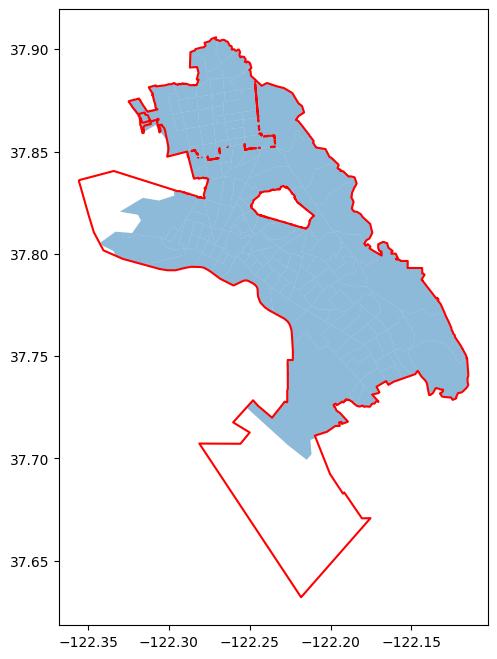

In [40]:
ax = oak_berk.boundary.plot(color="red", figsize=(8,8))
tcac_oak_berk.plot(ax=ax, alpha=0.5)

# **Saving TCAC Map Data For Future Visualization**
- Created HTML
- Create transferable file for future analysis

In [41]:
#tcac.save("/content/drive/MyDrive/255 Project Data/tcac_map.html")

In [42]:
gpd.read_file(
    os.path.join(DATA_DIR, "raw/berkeley city limits.zip")
)

In [43]:
tcac_oak_berk

,fips,fips_bg,county_name,region,pct_above_200_pov,pct_bachelors_plus,pct_employed,home_value,math_prof,read_prof,...,pct_asian,pct_black,pct_hispanic,pct_poc,pct_asian_cty,pct_black_cty,pct_hispanic_cty,pct_poc_cty,pov_seg_flag,geometry
0,06001400100,None,Alameda,Bay Area Region,0.912195,0.855738,0.784858,1802100.0,0.683709,0.711517,...,0.149321,NaN,NaN,0.319005,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.24691 37.88536, -122.2419..."
1,06001400200,None,Alameda,Bay Area Region,0.903966,0.839766,0.759462,1930000.0,0.665117,0.708944,...,0.122312,NaN,0.093645,0.327281,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.25742 37.8431, -122.2562 ..."
2,06001400300,None,Alameda,Bay Area Region,0.889960,0.807848,0.848602,1850900.0,0.431718,0.493813,...,0.106338,0.091496,NaN,0.412432,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26416 37.84, -122.26186 3..."
3,06001400400,None,Alameda,Bay Area Region,0.820271,0.807012,0.856718,1398400.0,0.553012,0.614790,...,0.096018,NaN,0.137429,0.398180,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.2618 37.84179, -122.2613 ..."
4,06001400500,None,Alameda,Bay Area Region,0.748166,0.681416,0.762106,1313500.0,0.528160,0.585979,...,0.080063,NaN,0.145735,0.556253,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26941 37.84811, -122.2683..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,06001424002,None,Alameda,Bay Area Region,0.756250,0.529317,0.786496,1176300.0,0.462152,0.493704,...,0.105365,0.245465,0.179081,0.593593,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.28679 37.85218, -122.2814..."
374,06001981900,None,Alameda,Bay Area Region,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.34225 37.80556, -122.3338..."
375,06001982000,None,Alameda,Bay Area Region,NaN,NaN,NaN,1028400.0,0.227492,0.234690,...,NaN,NaN,NaN,NaN,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.31321 37.7953, -122.30774..."
376,06001982100,None,Alameda,Bay Area Region,0.689655,NaN,0.660000,NaN,0.669748,0.725244,...,0.394904,NaN,0.171065,0.670610,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.26633 37.87419, -122.2653..."


In [44]:
print(f"File saved to: {output_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>